In [54]:
# pick any image from the dataset shared with you.
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('../assets/assignment.jpg')

In [60]:
# Convert the image to grayscale first
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Then convert the grayscale image into black and white using THRESH_BINARY
ret, thresh = cv.threshold(gray_img, 127, 255, cv.THRESH_BINARY)


In [61]:
mask_face_0 = cv.bitwise_not(thresh)

In [ ]:
def create_color(dimension, bgr):
  r = np.ones(dimension, dtype=np.uint8) * bgr[0]
  g = np.ones(dimension, dtype=np.uint8) * bgr[1]
  b = np.ones(dimension, dtype=np.uint8) * bgr[2]
  return cv.merge([b,g,r])


h, w = img.shape[:2]
dimension = (h, w)

#Re-create the blue background using the function
blue_bg = create_color(dimension, (255, 0, 0))

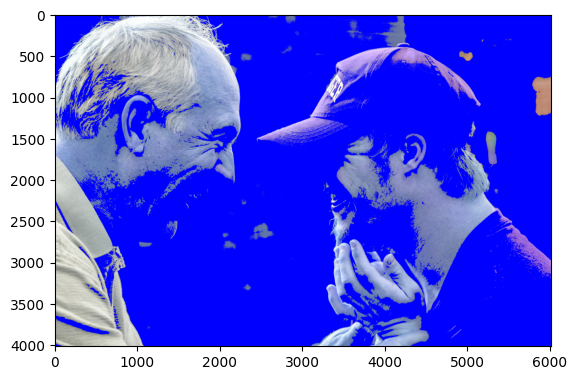

In [ ]:

target_size = (img.shape[1], img.shape[0])


thresh = cv.resize(thresh, target_size)
mask_face_0 = cv.resize(mask_face_0, target_size)

thresh = thresh.astype('uint8')
mask_face_0 = mask_face_0.astype('uint8')


final_output = cv.bitwise_and(img, img, mask=thresh)
background_part = cv.bitwise_and(blue_bg, blue_bg, mask=mask_face_0)

combined = cv.add(final_output, background_part)

plt.imshow(combined)